In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from optimization_project import modified_gauss_newton

import inspect
from optimization_project import problems as problems_module

problems = [
    cls() for name, cls in inspect.getmembers(problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

In [ ]:
def compute_metrics(problem, x_final, rss_final):
    
    metrics = {}

    if problem.certified_solution is not None:

        param_error = np.linalg.norm(
            x_final - problem.certified_solution
        )

        rel_param_error = (
            param_error /
            np.linalg.norm(problem.certified_solution)
        )

        metrics["parameter_error"] = param_error

    else:
        metrics["parameter_error"] = np.nan

    if problem.certified_rss is not None:
        metrics["rss_error"] = abs(
            rss_final - problem.certified_rss
        )
    else:
        metrics["rss_error"] = np.nan

    return metrics

In [ ]:
def run_lm(
    problem,
    x0,
    start_name,
    xtol=1e-6,
    ftol=1e-6,
    gtol=1e-6,
    max_nfev=1000
):

    # LM requires m >= n
    method = "lm" if problem.m >= problem.n else "trf"

    result = least_squares(
        fun=problem.F,
        jac=problem.J,
        x0=x0,
        method=method,
        xtol=xtol,
        ftol=ftol,
        gtol=gtol,
        max_nfev=max_nfev
    )

    x_final = result.x
    rss_final = np.sum(problem.F(x_final) ** 2)

    metrics = compute_metrics(
        problem,
        x_final,
        rss_final
    )

    row = {
        "problem": problem.name,
        "difficulty": problem.difficulty,
        "classification_model": problem.classification_model,

        "method": f"LM-{method}",
        "start_name": start_name,

        "success": result.success,

        "iterations": result.nfev,
        "final_rss": rss_final,

        "parameter_error": metrics["parameter_error"],
        "rss_error": metrics["rss_error"]
    }

    return row

In [ ]:
def run_modified_gn(
    problem,
    x0,
    start_name,
    M0=1e-3,
    L0=1e-6,
    M_search=2,
    tol=1e-6,
    max_iter=1000
):

    x_final, history = modified_gauss_newton(
        problem,
        x0,
        M0=M0,
        L0=L0,
        M_search=M_search,
        tol=tol,
        max_iter=max_iter,
        return_history=True
    )


    rss_final = np.sum(problem.F(x_final) ** 2)

    metrics = compute_metrics(
        problem,
        x_final,
        rss_final
    )

    row = {
        "problem": problem.name,
        "difficulty": problem.difficulty,
        "classification_model": problem.classification_model,

        "method": "ModifiedGN",
        "start_name": start_name,

        "success": history[-1] < tol if len(history) > 0 else False,

        "iterations": len(history),
        "final_rss": rss_final,

        "parameter_error": metrics["parameter_error"],
        "rss_error": metrics["rss_error"]
    }

    return row

In [13]:
def benchmark_methods(problems):

    rows = []

    for problem in problems:
        print(f"Running problem: {problem.name}")

        starts = problem.get_starting_points()

        for start_name, x0 in starts.items():

            row_mgn = run_modified_gn(problem, x0, start_name)
            rows.append(row_mgn)


            row_lm = run_lm(problem, x0, start_name)
            rows.append(row_lm)

    return pd.DataFrame(rows)

In [14]:
df_results = benchmark_methods(problems)

Running problem: Chwirut1
Modified Gauss-Newton Converged in 12 iterations.
Modified Gauss-Newton Converged in 12 iterations.
Running problem: DanWood
Modified Gauss-Newton Converged in 10 iterations.
Modified Gauss-Newton Converged in 5 iterations.
Running problem: Eckerle4
Modified Gauss-Newton Converged in 30 iterations.
Modified Gauss-Newton Converged in 7 iterations.
Running problem: MGH17


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])


Modified Gauss-Newton Converged in 88 iterations.


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


Modified Gauss-Newton Converged in 31 iterations.
Running problem: Roszman1
Running problem: Thurber


,problem,difficulty,classification_model,method,start_name,success,iterations,final_rss,parameter_error,rss_error,digits_accuracy
0,Chwirut1,Lower,Exponential,ModifiedGN,NIST Start 1,False,12,34.378592,2.073276e-01,2.350099e+03,-0.036379
1,Chwirut1,Lower,Exponential,LM-lm,NIST Start 1,True,11,34.378592,2.073280e-01,2.350099e+03,-0.036380
2,Chwirut1,Lower,Exponential,ModifiedGN,NIST Start 2,False,12,34.378592,2.073276e-01,2.350099e+03,-0.036379
3,Chwirut1,Lower,Exponential,LM-lm,NIST Start 2,True,13,34.378592,2.073276e-01,2.350099e+03,-0.036379
4,DanWood,Lower,Miscellaneous,ModifiedGN,NIST Start 1,False,10,0.004317,4.431338e-11,8.948571e-15,10.948545
5,DanWood,Lower,Miscellaneous,LM-lm,NIST Start 1,True,6,0.004317,2.480603e-08,8.687495e-15,8.200523
6,DanWood,Lower,Miscellaneous,ModifiedGN,NIST Start 2,False,5,0.004317,3.505451e-09,8.892193e-15,9.050336
7,DanWood,Lower,Miscellaneous,LM-lm,NIST Start 2,True,4,0.004317,5.923149e-07,1.181884e-13,6.822527
8,Eckerle4,Higher,Exponential,ModifiedGN,NIST Start 1,False,30,0.001464,1.044577e-08,2.747368e-14,10.635777
9,Eckerle4,Higher,Exponential,LM-lm,NIST Start 1,True,18,0.001464,5.552566e-06,6.197887e-13,7.910224


---

In [3]:
def compare_methods(problems):
    for problem in problems:
        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5))
        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # --- Modified Gauss-Newton ---
            x_gn, hist_mgn = modified_gauss_newton(
                problem, x0,
                M0=1e-3, L0=1e-6, M_search=2,
                tol=1e-8, max_iter=100,
                return_history=True
            )

            # --- SciPy ---
            x_sp, hist_sp = run_scipy_with_history(problem, x0)

            # --- rysowanie na danym subplot ---
            ax.semilogy(hist_mgn, label="Modified GN")
            ax.semilogy(hist_sp, label="SciPy LM")

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid()
            ax.legend()

        fig.suptitle(f"{problem.name} – convergence comparison", fontsize=14)

        plt.tight_layout()
        plt.show()


=== Chwirut1 ===
Modified Gauss-Newton Converged in 13 iterations.
Modified Gauss-Newton Converged in 59 iterations.


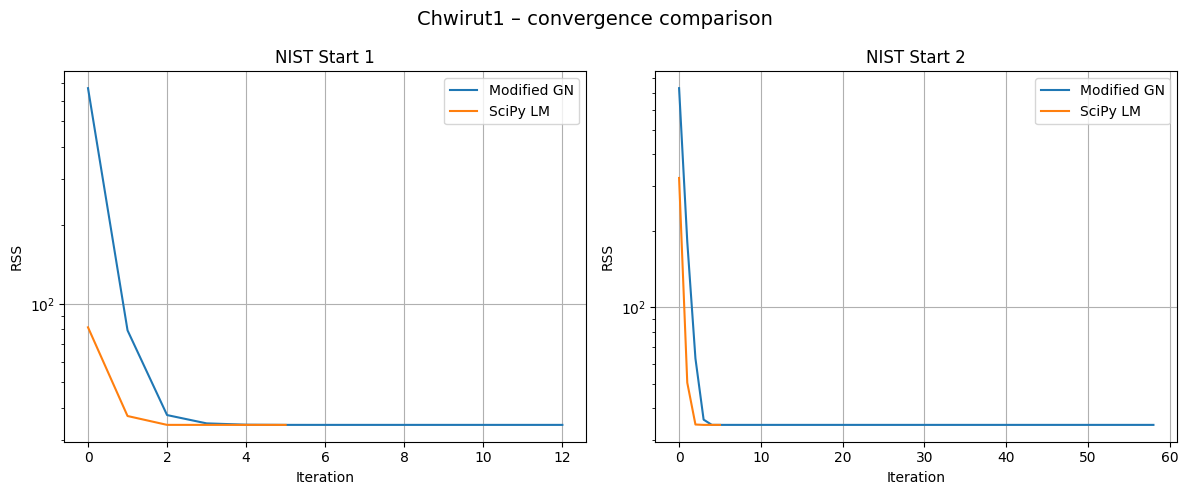


=== DanWood ===
Modified Gauss-Newton Converged in 10 iterations.
Modified Gauss-Newton Converged in 6 iterations.


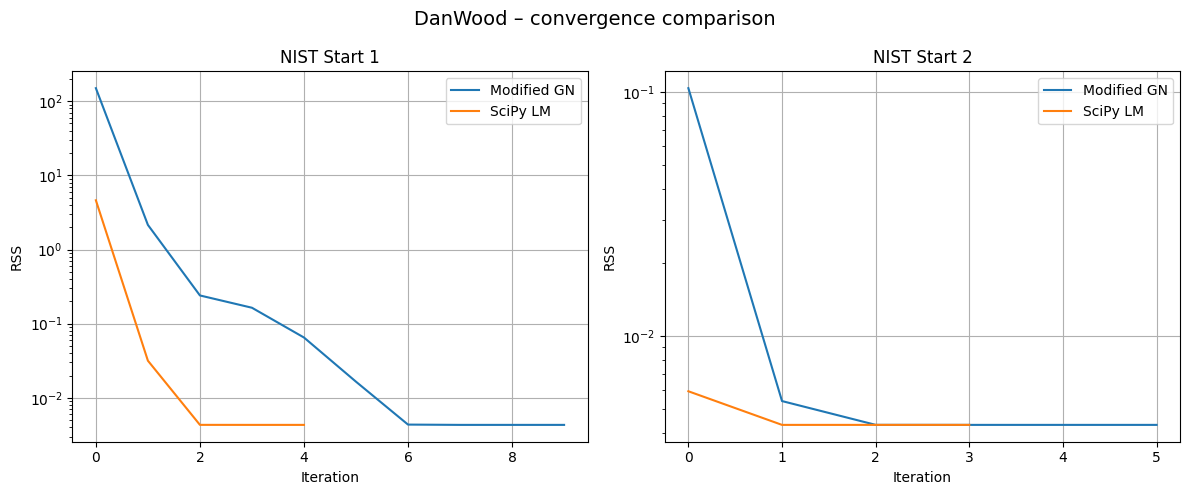


=== Eckerle4 ===
Modified Gauss-Newton Converged in 31 iterations.
Modified Gauss-Newton Converged in 9 iterations.


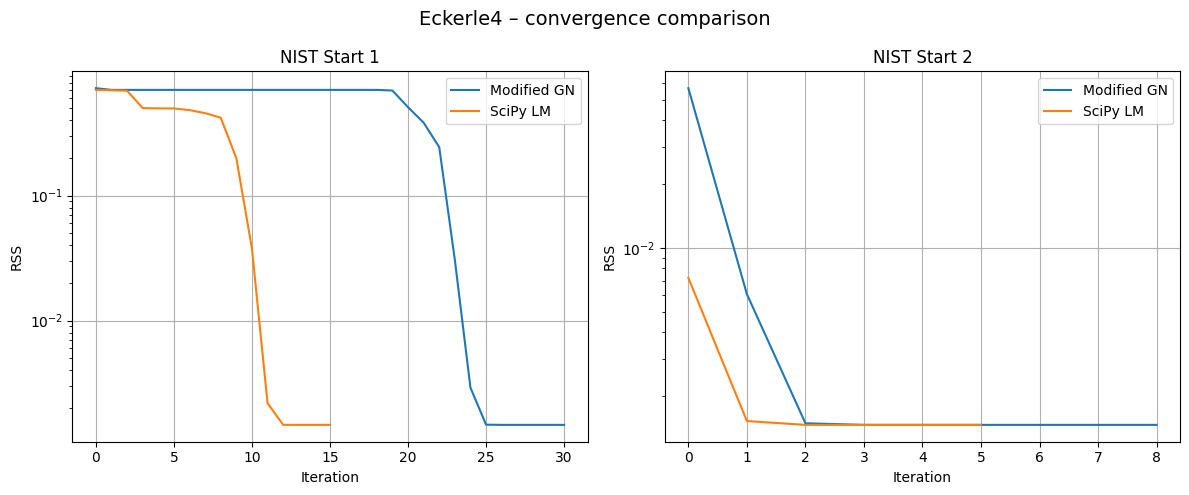


=== MGH17 ===


/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:32: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:32: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:33: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:31: RuntimeWarning: invalid value encountered in add
  b[0]


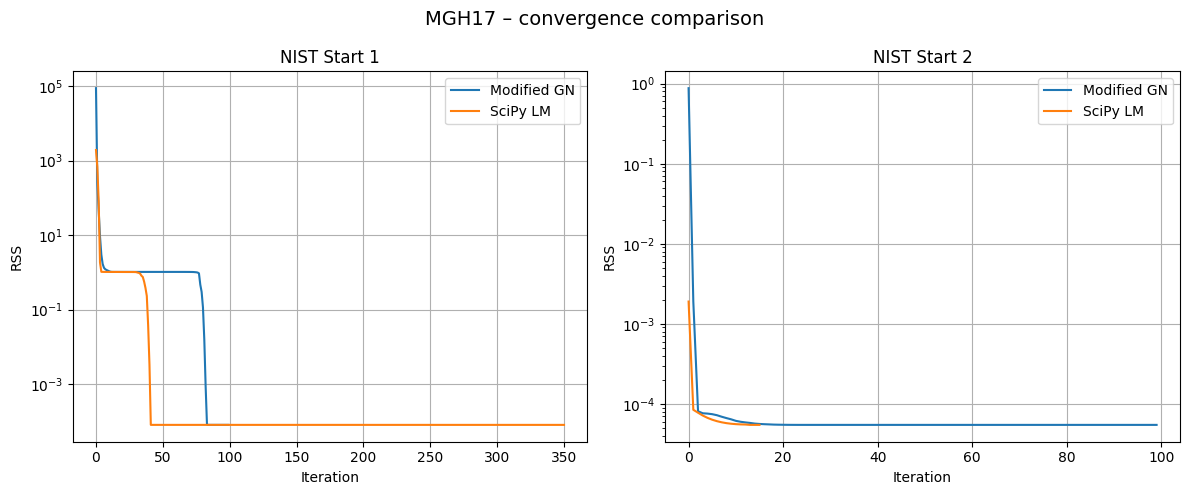


=== Roszman1 ===


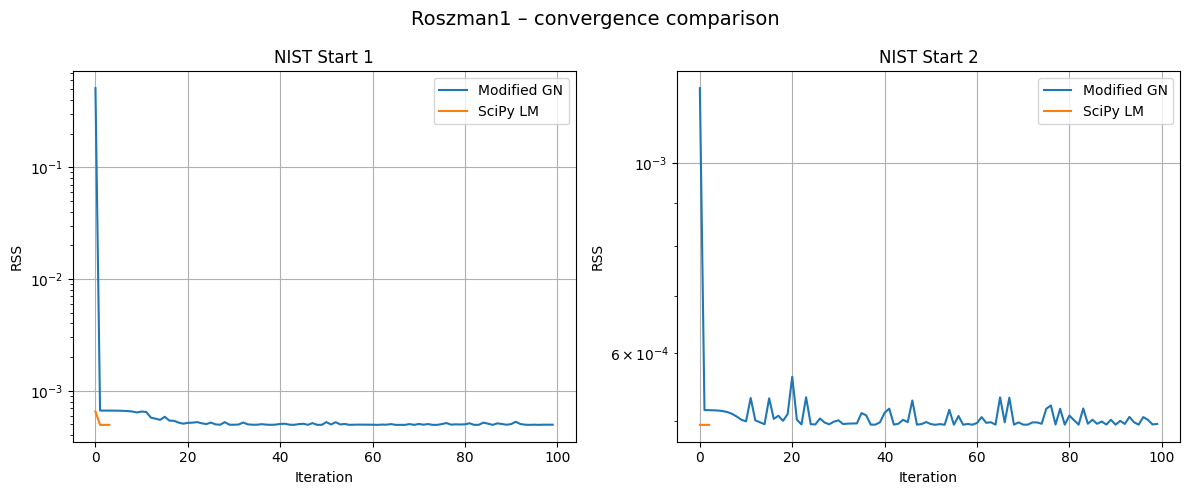


=== Thurber ===


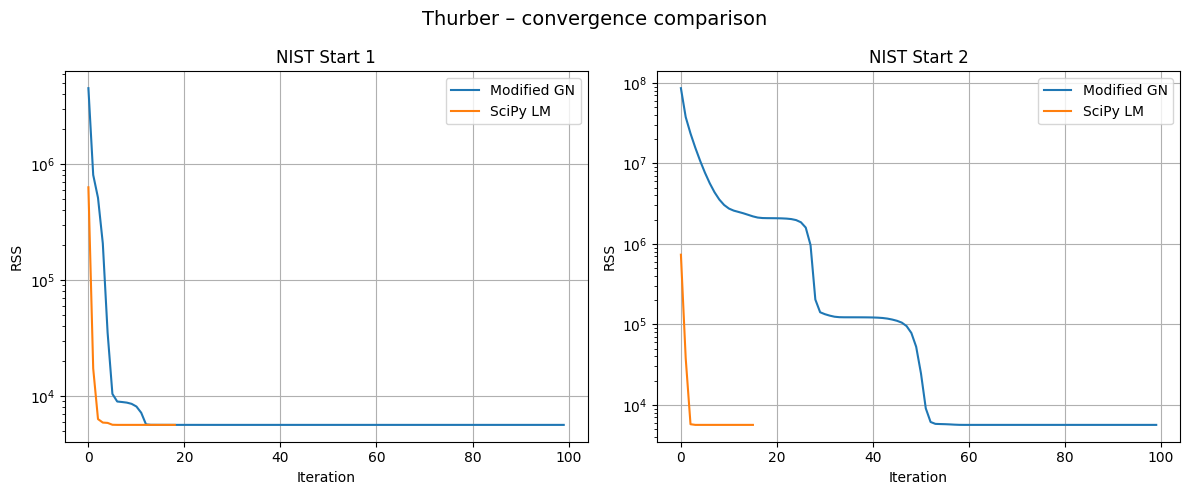

In [4]:
compare_methods(problems)

In [5]:
from optimization_project import gauss_newton_basic

def compare_methods(problems):
    for problem in problems:
        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5))
        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):
            print(f"\nStarting point: {name})")

            # --- Modified Gauss-Newton ---
            x_gn, hist_mgn = modified_gauss_newton(
                problem, x0,
                M0=1e-3, L0=1e-6, M_search=2,
                tol=1e-8, max_iter=100,
                return_history=True
            )

            # --- Basic Gauss-Newton ---
            x_gn_b, hist_gnb = gauss_newton_basic(
                problem, x0,
                tol=1e-12, max_iter=100,
                return_history=True
            )

            # --- SciPy ---
            x_sp, hist_sp = run_scipy_with_history(problem, x0)

            # --- rysowanie na danym subplot ---
            ax.semilogy(hist_mgn, label="Modified GN")
            ax.semilogy(hist_gnb, label="Basic GN")
            ax.semilogy(hist_sp, label="SciPy LM")

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid()
            ax.legend()

            print(f"The final RSS for Modified GN: {hist_mgn[-1]}")
            print(f"The final RSS for Basic GN: {hist_gnb[-1]}")
            print(f"The final RSS for SciPy LM: {hist_sp[-1]}")
            print(f"SciPy LM - Modified GN: {hist_sp[-1] - hist_mgn[-1]}")

        fig.suptitle(f"{problem.name} – convergence comparison", fontsize=14)

        plt.tight_layout()
        plt.show()


=== Chwirut1 ===

Starting point: NIST Start 1)
Modified Gauss-Newton Converged in 13 iterations.
Basic Gauss-Newton converged in 55 iterations.
The final RSS for Modified GN: 34.37859207568277
The final RSS for Basic GN: 1962.28125
The final RSS for SciPy LM: 34.378592075752834
SciPy LM - Modified GN: 7.006661917330348e-11

Starting point: NIST Start 2)
Modified Gauss-Newton Converged in 59 iterations.
Basic Gauss-Newton converged in 46 iterations.
The final RSS for Modified GN: 34.37859207568276
The final RSS for Basic GN: 1962.28125
The final RSS for SciPy LM: 34.378592076361166
SciPy LM - Modified GN: 6.784048878216709e-10


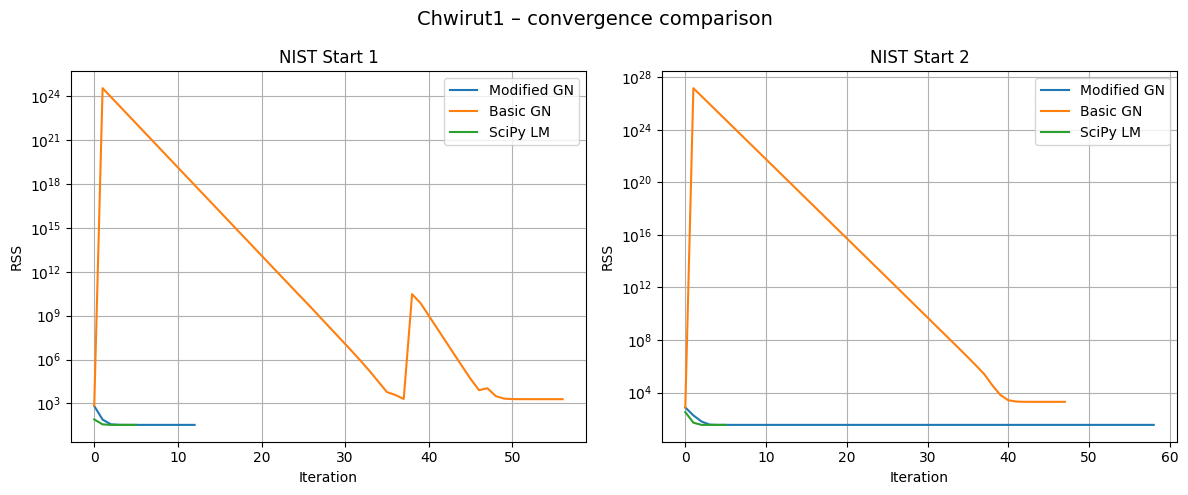


=== DanWood ===

Starting point: NIST Start 1)
Modified Gauss-Newton Converged in 10 iterations.
Basic Gauss-Newton converged in 8 iterations.
The final RSS for Modified GN: 0.004317308408291035
The final RSS for Basic GN: 0.004317308408291082
The final RSS for SciPy LM: 0.004317308408291267
SciPy LM - Modified GN: 2.3158558404290375e-16

Starting point: NIST Start 2)
Modified Gauss-Newton Converged in 6 iterations.
Basic Gauss-Newton converged in 6 iterations.
The final RSS for Modified GN: 0.0043173084082910795
The final RSS for Basic GN: 0.004317308408291036
The final RSS for SciPy LM: 0.004317308408291087
SciPy LM - Modified GN: 7.806255641895632e-18


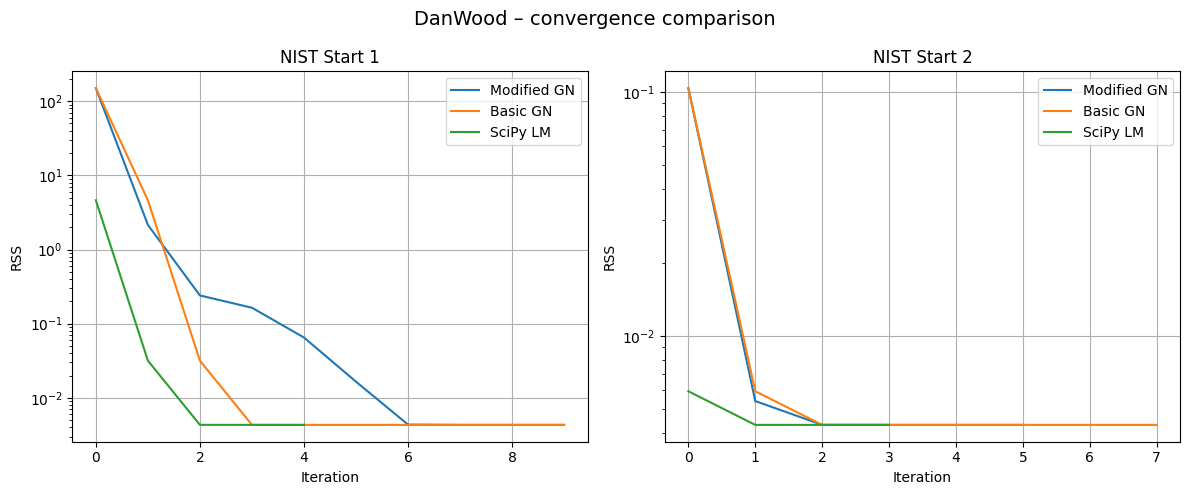


=== Eckerle4 ===

Starting point: NIST Start 1)
Modified Gauss-Newton Converged in 31 iterations.
The final RSS for Modified GN: 0.0014635887487274735
The final RSS for Basic GN: 0.49854321310126287
The final RSS for SciPy LM: 0.0014635887487368334
SciPy LM - Modified GN: 9.35991735506736e-15

Starting point: NIST Start 2)
Modified Gauss-Newton Converged in 9 iterations.
Basic Gauss-Newton converged in 11 iterations.
The final RSS for Modified GN: 0.0014635887487274711
The final RSS for Basic GN: 0.0014635887487274729
The final RSS for SciPy LM: 0.0014635887487304791
SciPy LM - Modified GN: 3.0080105073437835e-15


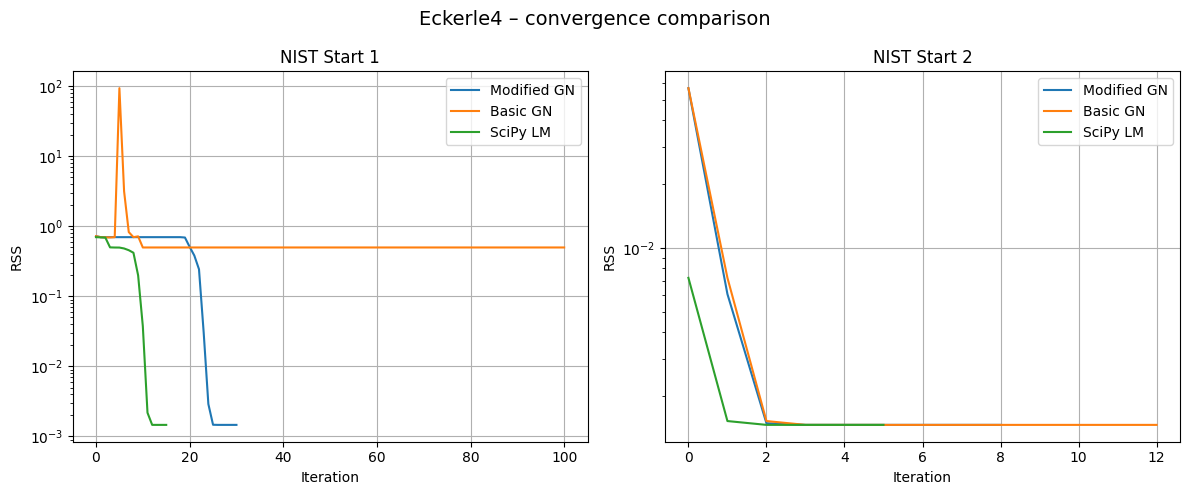


=== MGH17 ===

Starting point: NIST Start 1)
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
The final RSS for Modified GN: 7.978696447708051e-05
The final RSS for Basic GN: nan
The final RSS for SciPy LM: 7.973816132655101e-05
SciPy LM - Modified GN: -4.880315052950492e-08

Starting point: NIST Start 2)


/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:43: RuntimeWarning: overflow encountered in exp
  exp4 = np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/problems_average.py:44: RuntimeWarning: overflow encountered in exp
  exp5 = np.exp(-x * b[4])


Basic Gauss-Newton converged in 10 iterations.
The final RSS for Modified GN: 5.464894711099275e-05
The final RSS for Basic GN: 5.4648946974831276e-05
The final RSS for SciPy LM: 5.4648946974830104e-05
SciPy LM - Modified GN: -1.3616264691283797e-13


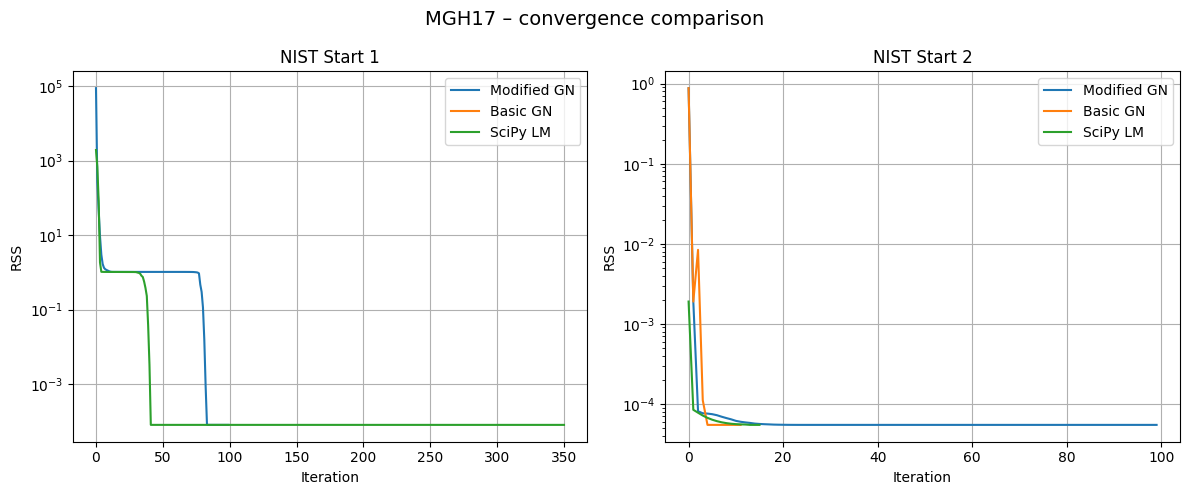


=== Roszman1 ===

Starting point: NIST Start 1)
Basic Gauss-Newton converged in 10 iterations.
The final RSS for Modified GN: 0.0004968038505137881
The final RSS for Basic GN: 0.0004948484733096877
The final RSS for SciPy LM: 0.0004948484733110186
SciPy LM - Modified GN: -1.955377202769444e-06

Starting point: NIST Start 2)
Basic Gauss-Newton converged in 9 iterations.
The final RSS for Modified GN: 0.0004961092452267171
The final RSS for Basic GN: 0.000494848473309688
The final RSS for SciPy LM: 0.000494848473310964
SciPy LM - Modified GN: -1.2607719157531035e-06


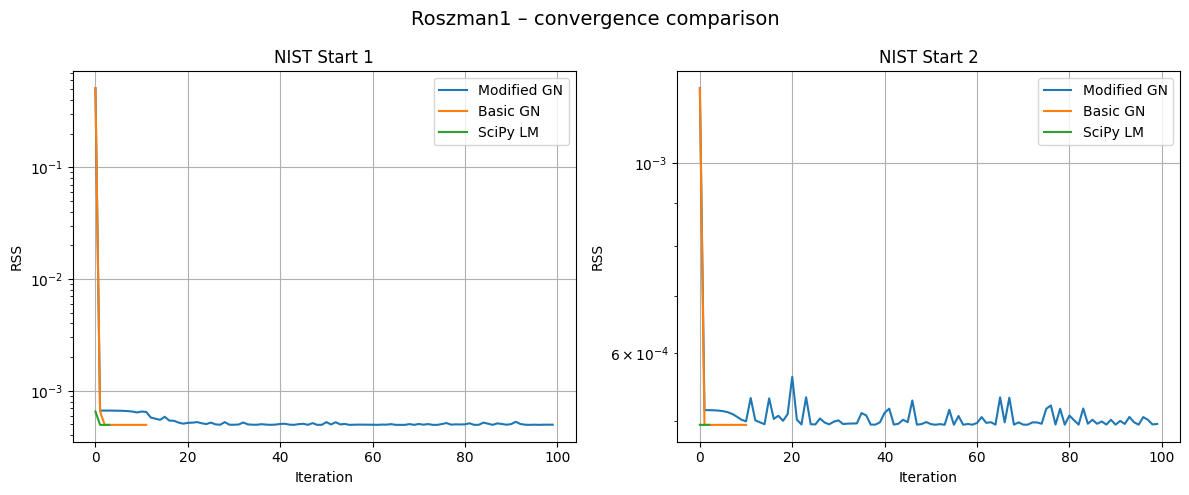


=== Thurber ===

Starting point: NIST Start 1)
The final RSS for Modified GN: 5642.70823966697
The final RSS for Basic GN: 14280.955986275401
The final RSS for SciPy LM: 5642.708270193183
SciPy LM - Modified GN: 3.052621286769863e-05

Starting point: NIST Start 2)
Basic Gauss-Newton converged in 71 iterations.
The final RSS for Modified GN: 5642.708239666914
The final RSS for Basic GN: 5642.708239666965
The final RSS for SciPy LM: 5642.708277486435
SciPy LM - Modified GN: 3.781952091230778e-05


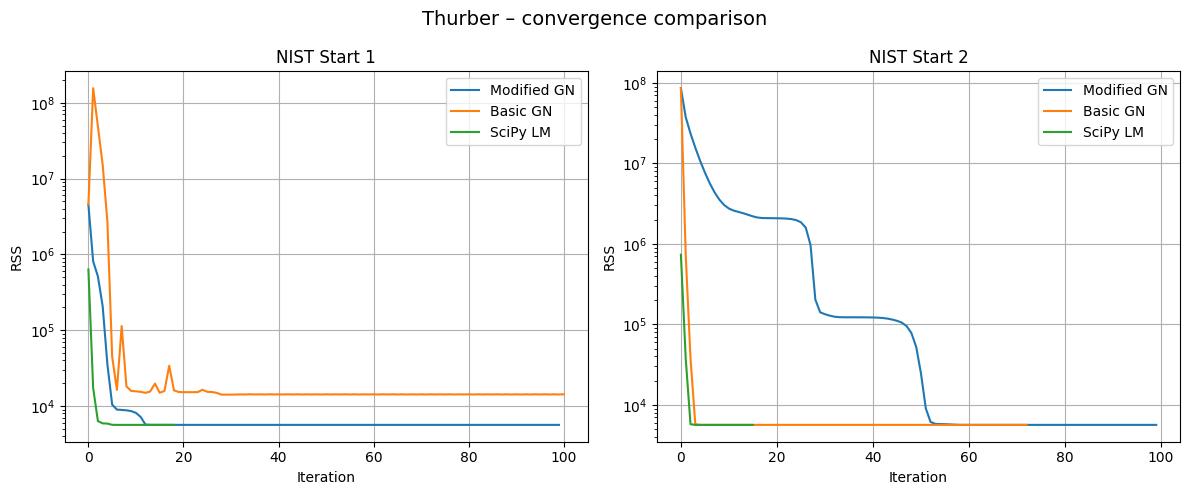

In [6]:
compare_methods(problems)